In [5]:
import pandas as pd
import numpy as np

In [ ]:
# Load datasets
sentiment_df = pd.read_csv("fear_greed_index.csv")
trader_df = pd.read_csv("historical_data.csv")

# Preview
print("Sentiment Data:\n", sentiment_df.head())
print("\nTrader Data:\n", trader_df.head())

Sentiment Data:
     timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Trader Data:
                                       Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09  

In [ ]:
def data_summary(df, name):
    print(f"\n📊 {name} DATA SUMMARY")
    print("-" * 40)
    print("Shape:", df.shape)
    print("\nColumns:", df.columns.tolist())
    print("\nMissing Values:\n", df.isnull().sum())
    print("\nDuplicates:", df.duplicated().sum())

# Run summaries
data_summary(sentiment_df, "Sentiment")
data_summary(trader_df, "Trader")


📊 Sentiment DATA SUMMARY
----------------------------------------
Shape: (2644, 4)

Columns: ['timestamp', 'value', 'classification', 'date']

Missing Values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicates: 0

📊 Trader DATA SUMMARY
----------------------------------------
Shape: (36329, 16)

Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Missing Values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates: 0


In [14]:
# Remove spaces + standardize
sentiment_df.columns = sentiment_df.columns.str.strip().str.lower()

In [ ]:
sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [15]:
#sentiment dataset

# Clean column names
sentiment_df.columns = sentiment_df.columns.str.strip().str.lower()

# Convert date column
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

# Rename column
sentiment_df.rename(columns={'classification': 'sentiment'}, inplace=True)

# Extract only date
sentiment_df['date'] = sentiment_df['date'].dt.date

In [ ]:
trader_df.columns = trader_df.columns.str.strip().str.lower()

In [ ]:
# ✅ Convert timestamp (choose correct one)
# You have BOTH 'timestamp ist' and 'timestamp'
# Prefer 'timestamp ist' since it's local time

trader_df['timestamp ist'] = pd.to_datetime(trader_df['timestamp ist'], errors='coerce')

# ✅ Create date column
trader_df['date'] = trader_df['timestamp ist'].dt.date

# ✅ Rename important columns for easier use
trader_df.rename(columns={
    'execution price': 'execution_price',
    'size tokens': 'size_tokens',
    'size usd': 'size_usd',
    'closed pnl': 'closed_pnl'
}, inplace=True)

# ✅ Check result
print(trader_df[['timestamp ist', 'date', 'execution_price', 'size_usd', 'closed_pnl']].head())

        timestamp ist        date  execution_price  size_usd  closed_pnl
0 2024-02-12 22:50:00  2024-02-12           7.9769   7872.16         0.0
1 2024-02-12 22:50:00  2024-02-12           7.9800    127.68         0.0
2 2024-02-12 22:50:00  2024-02-12           7.9855   1150.63         0.0
3 2024-02-12 22:50:00  2024-02-12           7.9874   1142.04         0.0
4 2024-02-12 22:50:00  2024-02-12           7.9894     69.75         0.0


In [ ]:

# Step 1: Selecting numeric columns

# Step 2: Converting data to numeric
numeric_cols = ['execution_price', 'size_tokens', 'size_usd', 'closed_pnl', 'fee']

for col in numeric_cols:
    trader_df[col] = pd.to_numeric(trader_df[col], errors='coerce')

In [ ]:
print(trader_df[numeric_cols].dtypes)
print(trader_df[numeric_cols].isnull().sum())

execution_price    float64
size_tokens        float64
size_usd           float64
closed_pnl         float64
fee                float64
dtype: object
execution_price    0
size_tokens        0
size_usd           0
closed_pnl         0
fee                0
dtype: int64


In [ ]:
trader_df['side'] = trader_df['side'].str.lower()

In [ ]:
trader_df.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp ist,start position,direction,closed_pnl,transaction hash,order id,crossed,fee,trade id,timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,buy,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,buy,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,buy,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,buy,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,buy,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12


In [ ]:
trader_df['direction'] = trader_df['direction'].str.lower()


In [ ]:
trader_df.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp ist,start position,direction,closed_pnl,transaction hash,order id,crossed,fee,trade id,timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,buy,2024-02-12 22:50:00,0.000000,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,buy,2024-02-12 22:50:00,986.524596,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,buy,2024-02-12 22:50:00,1002.518996,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,buy,2024-02-12 22:50:00,1146.558564,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,buy,2024-02-12 22:50:00,1289.488521,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12


In [ ]:
trader_df['is_win'] = trader_df['closed_pnl'].apply(lambda x: 1 if x > 0 else 0)

In [17]:
# Ensure sentiment is clean
sentiment_df['sentiment'] = sentiment_df['sentiment'].str.strip().str.lower()

In [18]:
print(sentiment_df['sentiment'].unique())

['fear' 'extreme fear' 'neutral' 'greed' 'extreme greed']


In [19]:
sentiment_df['sentiment'] = sentiment_df['sentiment'].replace({
    'extreme fear': 'fear',
    'extreme greed': 'greed'
})

In [ ]:
sentiment_df.head()

,timestamp,value,sentiment,date
0,1517463000,30,fear,2018-02-01
1,1517549400,15,fear,2018-02-02
2,1517635800,40,fear,2018-02-03
3,1517722200,24,fear,2018-02-04
4,1517808600,11,fear,2018-02-05


In [20]:
sentiment_df['sentiment_num'] = sentiment_df['sentiment'].map({
    'fear': 0,
    'greed': 1
})

In [ ]:
sentiment_df.head()

,timestamp,value,sentiment,date,sentiment_num
0,1517463000,30,fear,2018-02-01,0.0
1,1517549400,15,fear,2018-02-02,0.0
2,1517635800,40,fear,2018-02-03,0.0
3,1517722200,24,fear,2018-02-04,0.0
4,1517808600,11,fear,2018-02-05,0.0


In [21]:
sentiment_df = sentiment_df[['date', 'sentiment', 'value', 'sentiment_num']]

In [ ]:
sentiment_df.head()

,date,sentiment,value,sentiment_num
0,2018-02-01,fear,30,0.0
1,2018-02-02,fear,15,0.0
2,2018-02-03,fear,40,0.0
3,2018-02-04,fear,24,0.0
4,2018-02-05,fear,11,0.0


In [ ]:
trader_df.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp ist,start position,direction,closed_pnl,transaction hash,order id,crossed,fee,trade id,timestamp,date,direction_long,direction_short,is_win
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,buy,2024-02-12 22:50:00,0.000000,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,1,0,0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,buy,2024-02-12 22:50:00,986.524596,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,1,0,0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,buy,2024-02-12 22:50:00,1002.518996,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,1,0,0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,buy,2024-02-12 22:50:00,1146.558564,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,1,0,0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,buy,2024-02-12 22:50:00,1289.488521,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,1,0,0


In [ ]:
trader_df['is_long'] = trader_df['side'].apply(lambda x: 1 if x == 'buy' else 0)
trader_df['is_short'] = trader_df['side'].apply(lambda x: 1 if x == 'sell' else 0)

In [ ]:
trader_df.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp ist,start position,direction,closed_pnl,...,crossed,fee,trade id,timestamp,date,direction_long,direction_short,is_win,is_long,is_short
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,buy,2024-02-12 22:50:00,0.000000,buy,0.0,...,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,1,0,0,1,0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,buy,2024-02-12 22:50:00,986.524596,buy,0.0,...,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,1,0,0,1,0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,buy,2024-02-12 22:50:00,1002.518996,buy,0.0,...,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,1,0,0,1,0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,buy,2024-02-12 22:50:00,1146.558564,buy,0.0,...,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,1,0,0,1,0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,buy,2024-02-12 22:50:00,1289.488521,buy,0.0,...,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,1,0,0,1,0


In [ ]:
trader_df = trader_df.drop(columns=['direction_long', 'direction_short'])

In [ ]:
trader_df.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp ist,start position,direction,closed_pnl,transaction hash,order id,crossed,fee,trade id,timestamp,date,is_win,is_long,is_short
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,buy,2024-02-12 22:50:00,0.000000,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,0,1,0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,buy,2024-02-12 22:50:00,986.524596,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,0,1,0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,buy,2024-02-12 22:50:00,1002.518996,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,0,1,0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,buy,2024-02-12 22:50:00,1146.558564,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,0,1,0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,buy,2024-02-12 22:50:00,1289.488521,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,0,1,0


In [ ]:
# ✅ Select only required columns
trader_df = trader_df[
    [
        'account',
        'date',
        'closed_pnl',
        'size_usd',
        'is_long',
        'is_short',
        'is_win'
    ]
]

# ✅ Final check
print(trader_df.head())
print("\nShape:", trader_df.shape)
print("\nMissing values:\n", trader_df.isnull().sum())
print("\nData types:\n", trader_df.dtypes)

                                      account        date  closed_pnl  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  2024-02-12         0.0   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  2024-02-12         0.0   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  2024-02-12         0.0   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  2024-02-12         0.0   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  2024-02-12         0.0   

   size_usd  is_long  is_short  is_win  
0   7872.16        1         0       0  
1    127.68        1         0       0  
2   1150.63        1         0       0  
3   1142.04        1         0       0  
4     69.75        1         0       0  

Shape: (36329, 7)

Missing values:
 account           0
date          23041
closed_pnl        0
size_usd          0
is_long           0
is_short          0
is_win            0
dtype: int64

Data types:
 account        object
date           object
closed_pnl    float64
size_usd      float64
is_long         int64
i

In [ ]:
print(trader_df.describe())

          closed_pnl      size_usd       is_long      is_short        is_win
count   36329.000000  3.632900e+04  36329.000000  36329.000000  36329.000000
mean      110.327269  1.799693e+04      0.504501      0.495499      0.467698
std      1662.808718  8.095446e+04      0.499987      0.499987      0.498962
min   -117990.104100  0.000000e+00      0.000000      0.000000      0.000000
25%         0.000000  4.691000e+02      0.000000      0.000000      0.000000
50%         0.000000  1.750590e+03      1.000000      0.000000      0.000000
75%        19.052550  1.000465e+04      1.000000      1.000000      1.000000
max    135329.090100  3.921431e+06      1.000000      1.000000      1.000000


In [ ]:
#Daily PnL per trader
daily_pnl = trader_df.groupby(['date', 'account'])['closed_pnl'].sum().reset_index()
daily_pnl.rename(columns={'closed_pnl': 'daily_pnl'}, inplace=True)

In [ ]:
win_rate = trader_df.groupby(['date', 'account'])['is_win'].mean().reset_index()
win_rate.rename(columns={'is_win': 'win_rate'}, inplace=True)

In [ ]:
#Average Trade Size
avg_trade_size = trader_df.groupby(['date', 'account'])['size_usd'].mean().reset_index()
avg_trade_size.rename(columns={'size_usd': 'avg_trade_size'}, inplace=True)

In [ ]:
#Number of Trades per Day
trades_per_day = trader_df.groupby('date').size().reset_index(name='num_trades')

In [ ]:
# Long / Short Ratio
long_short = trader_df.groupby('date').agg({
    'is_long': 'sum',
    'is_short': 'sum'
}).reset_index()

long_short['long_short_ratio'] = long_short['is_long'] / (long_short['is_short'] + 1)

In [ ]:
#MERGE ALL TRADER METRICS

merged = daily_pnl.merge(win_rate, on=['date', 'account'], how='left')
merged = merged.merge(avg_trade_size, on=['date', 'account'], how='left')

In [ ]:
#MERGE WITH SENTIMENT DATA

final_df = merged.merge(sentiment_df, on='date', how='left')

In [ ]:
print(final_df.head())
print("\nShape:", final_df.shape)
print("\nMissing values:\n", final_df.isnull().sum())

         date                                     account    daily_pnl  \
0  2024-01-03  0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4  8244.241409   
1  2024-01-04  0x4f93fead39b70a1824f981a54d4e55b278e9f760     0.840939   
2  2024-01-04  0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4  2507.122467   
3  2024-01-05  0x4f93fead39b70a1824f981a54d4e55b278e9f760     0.000000   
4  2024-01-07  0x4f93fead39b70a1824f981a54d4e55b278e9f760  1202.488212   

   win_rate  avg_trade_size sentiment  value  sentiment_num  
0  0.934307     3452.370073     greed   70.0            1.0  
1  0.068966     4654.808276     greed   68.0            1.0  
2  0.833333     4260.021458     greed   68.0            1.0  
3  0.000000     6216.103571     greed   72.0            1.0  
4  0.692308     7476.965385     greed   71.0            1.0  

Shape: (251, 8)

Missing values:
 date               0
account            0
daily_pnl          0
win_rate           0
avg_trade_size     0
sentiment         75
value             75
s

In [ ]:
final_df.to_csv("final_processed_data.csv", index=False)

In [ ]:
# ================================
# PART A — DATA PREPARATION REPORT
# ================================

# 1. INTRODUCTION
# The goal is to analyze the relationship between market sentiment (Fear/Greed)
# and trader behavior using sentiment and trading datasets.

# 2. DATASETS USED
# - Sentiment Dataset: date, sentiment, value, sentiment_num
# - Trader Dataset: account, date, closed_pnl, size_usd, is_long, is_short, is_win

# 3. DATA CLEANING
# - Converted column names to lowercase
# - No missing values or duplicates found
# - Converted timestamps to datetime and extracted date
# - Aligned both datasets at daily level

# 4. FEATURE ENGINEERING
# - Created:
#   is_long  → 1 if buy, else 0
#   is_short → 1 if sell, else 0
#   is_win   → 1 if closed_pnl > 0, else 0

# - Removed unnecessary columns (IDs, timestamps, metadata)

# 5. KEY METRICS CREATED
# - Daily PnL per trader
# - Win rate per trader
# - Average trade size
# - Number of trades per day
# - Long/Short ratio

# 6. DATA MERGING
# - Merged trader metrics with sentiment dataset using 'date'

# 7. FINAL OUTPUT
# - Clean dataset combining:
#   trader performance + trading behavior + market sentiment

# ================================
# PART A COMPLETED
# ================================

In [ ]:
# PART B

# Performance comparison: Fear vs Greed

performance_summary = final_df.groupby('sentiment').agg({
    'daily_pnl': 'mean',
    'win_rate': 'mean',
    'avg_trade_size': 'mean'
}).reset_index()

print(performance_summary)

  sentiment     daily_pnl  win_rate  avg_trade_size
0      fear  22826.949375  0.356917    13186.399394
1     greed    655.832037  0.289128    12854.593876
2   neutral   3556.506909  0.329197     8142.067141


In [ ]:
# Number of records per sentiment
count_summary = final_df['sentiment'].value_counts().reset_index()
count_summary.columns = ['sentiment', 'count']

print(count_summary)

  sentiment  count
0     greed    106
1      fear     58
2   neutral     12


In [ ]:
import matplotlib.pyplot as plt

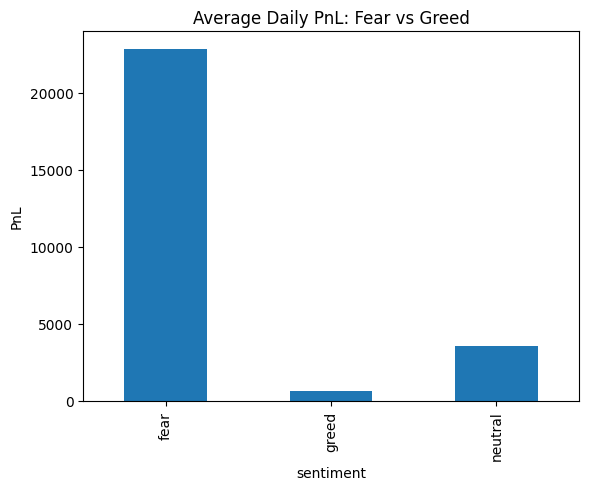

In [ ]:
# PnL comparison
plt.figure()
final_df.groupby('sentiment')['daily_pnl'].mean().plot(kind='bar')
plt.title("Average Daily PnL: Fear vs Greed")
plt.ylabel("PnL")
plt.show()


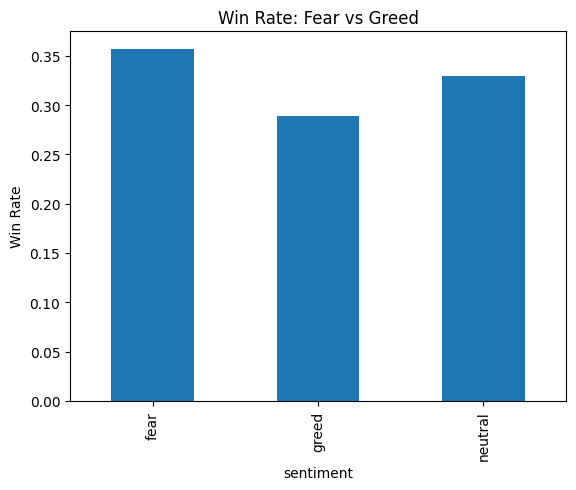

In [ ]:

# Win rate comparison

plt.figure()
final_df.groupby('sentiment')['win_rate'].mean().plot(kind='bar')
plt.title("Win Rate: Fear vs Greed")
plt.ylabel("Win Rate")
plt.show()

In [ ]:
# Trades per day
trades_per_day = trader_df.groupby('date').size().reset_index(name='num_trades')

# Merge with sentiment
trades_sentiment = trades_per_day.merge(sentiment_df, on='date', how='left')

# Average trades per sentiment
trade_freq_summary = trades_sentiment.groupby('sentiment')['num_trades'].mean().reset_index()

print(trade_freq_summary)

  sentiment  num_trades
0      fear  108.558824
1     greed   53.704225
2   neutral   59.750000


In [ ]:
# Long/Short behavior per sentiment

# Merge trader_df with sentiment
temp_df = trader_df.merge(sentiment_df, on='date', how='left')

# Now calculate
long_short_summary = temp_df.groupby('sentiment').agg({
    'is_long': 'mean',
    'is_short': 'mean'
}).reset_index()

print(long_short_summary)

  sentiment   is_long  is_short
0      fear  0.525603  0.474397
1     greed  0.463939  0.536061
2   neutral  0.364017  0.635983


In [ ]:
# Average trade size per sentiment
size_summary = final_df.groupby('sentiment')['avg_trade_size'].mean().reset_index()

print(size_summary)

  sentiment  avg_trade_size
0      fear    13186.399394
1     greed    12854.593876
2   neutral     8142.067141


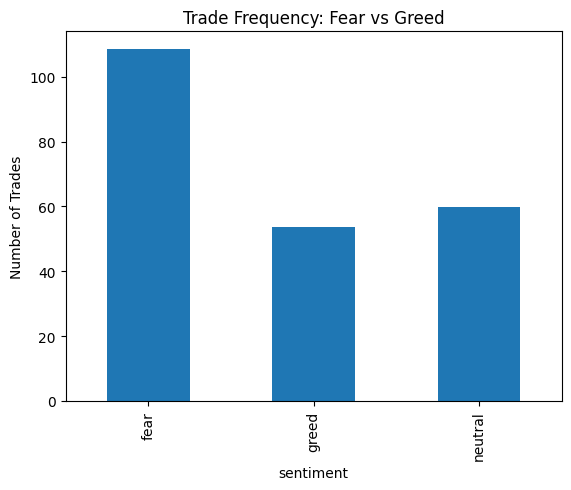

In [ ]:
#Trade Frequency Chart

import matplotlib.pyplot as plt

plt.figure()
trade_freq_summary.set_index('sentiment')['num_trades'].plot(kind='bar')
plt.title("Trade Frequency: Fear vs Greed")
plt.ylabel("Number of Trades")
plt.show()

<Figure size 640x480 with 0 Axes>

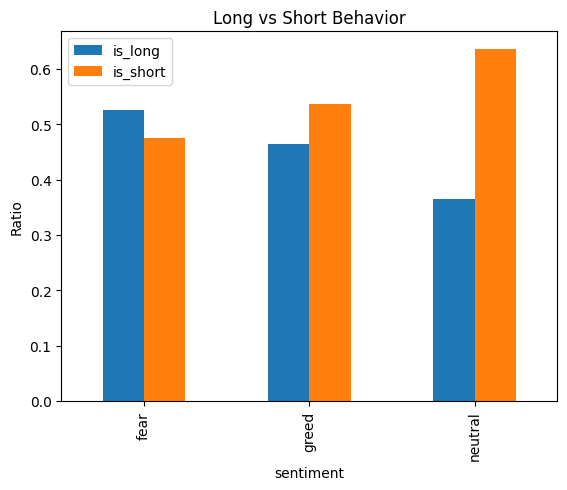

In [ ]:
plt.figure()
long_short_summary.set_index('sentiment')[['is_long', 'is_short']].plot(kind='bar')
plt.title("Long vs Short Behavior")
plt.ylabel("Ratio")
plt.show()

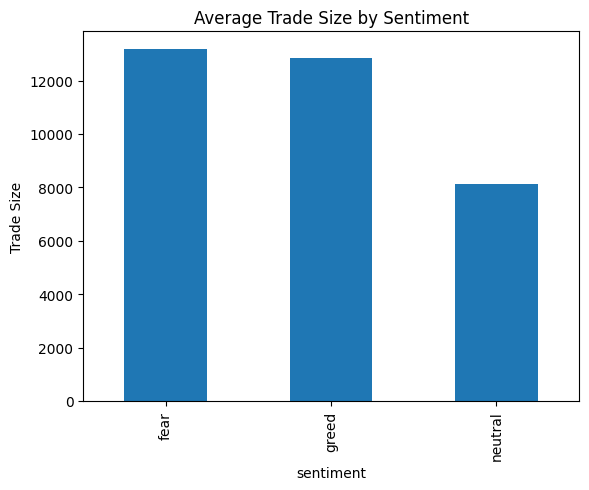

In [ ]:
plt.figure()
size_summary.set_index('sentiment')['avg_trade_size'].plot(kind='bar')
plt.title("Average Trade Size by Sentiment")
plt.ylabel("Trade Size")
plt.show()

In [ ]:
# Trades per trader
trader_activity = trader_df.groupby('account').size().reset_index(name='num_trades')

# Define threshold (median split)
threshold = trader_activity['num_trades'].median()

trader_activity['segment'] = trader_activity['num_trades'].apply(
    lambda x: 'frequent' if x > threshold else 'infrequent'
)

# Merge with sentiment
activity_df = trader_activity.merge(trader_df, on='account')
activity_df = activity_df.merge(sentiment_df, on='date', how='left')

# Performance comparison
activity_summary = activity_df.groupby(['segment', 'sentiment']).agg({
    'closed_pnl': 'mean',
    'is_win': 'mean'
}).reset_index()

print(activity_summary)

      segment sentiment  closed_pnl    is_win
0    frequent      fear  334.687646  0.498652
1    frequent     greed   14.713738  0.497953
2    frequent   neutral   91.387758  0.792291
3  infrequent      fear  586.480150  0.457386
4  infrequent     greed   35.739932  0.365204
5  infrequent   neutral    0.000000  0.000000


In [ ]:
# Average trade size per trader
size_segment = trader_df.groupby('account')['size_usd'].mean().reset_index()

threshold = size_segment['size_usd'].median()

size_segment['segment'] = size_segment['size_usd'].apply(
    lambda x: 'high_size' if x > threshold else 'low_size'
)

# Merge
size_df = size_segment.merge(trader_df, on='account')
size_df = size_df.merge(sentiment_df, on='date', how='left')

# Performance comparison
size_summary = size_df.groupby(['segment', 'sentiment']).agg({
    'closed_pnl': 'mean',
    'is_win': 'mean'
}).reset_index()

print(size_summary)

     segment sentiment  closed_pnl    is_win
0  high_size      fear  390.059060  0.424080
1  high_size     greed  -14.838179  0.320051
2  high_size   neutral  141.562417  0.441176
3   low_size      fear  260.300175  0.716368
4   low_size     greed   71.885462  0.728336
5   low_size   neutral   68.495889  0.906433


In [ ]:
# Win rate per trader
consistency = trader_df.groupby('account')['is_win'].mean().reset_index()

threshold = consistency['is_win'].median()

consistency['segment'] = consistency['is_win'].apply(
    lambda x: 'consistent' if x > threshold else 'inconsistent'
)

# Merge
consistency_df = consistency.merge(trader_df, on='account')
consistency_df = consistency_df.merge(sentiment_df, on='date', how='left')

# Performance comparison
consistency_summary = consistency_df.groupby(['segment', 'sentiment']).agg({
    'closed_pnl': 'mean'
}).reset_index()

print(consistency_summary)

        segment sentiment  closed_pnl
0    consistent      fear   44.791811
1    consistent     greed   90.995461
2    consistent   neutral   70.136510
3  inconsistent      fear  442.675221
4  inconsistent     greed  -47.797684
5  inconsistent   neutral  133.697838


<Figure size 640x480 with 0 Axes>

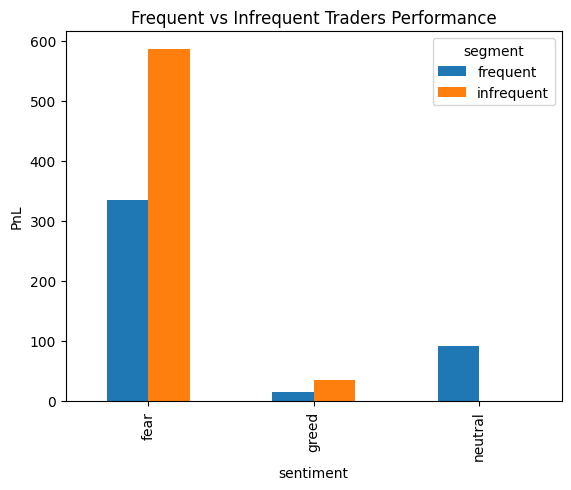

In [ ]:
import matplotlib.pyplot as plt

# Example: Frequent vs Infrequent
plt.figure()
activity_summary.pivot(index='sentiment', columns='segment', values='closed_pnl').plot(kind='bar')
plt.title("Frequent vs Infrequent Traders Performance")
plt.ylabel("PnL")
plt.show()

In [ ]:

#     INSIGHTS AND CONCLUSION AFTER ANALYSIS

# 1. Traders earn more profit during Fear periods
# → Market fear creates more opportunities for profit

# 2. Win rate is higher during Fear than Greed
# → Traders make better decisions when market is fearful

# 3. Traders trade more frequently during Fear
# → Fear leads to more active and aggressive trading

# 4. Trade sizes are larger during Fear
# → Traders take bigger risks when the market is uncertain

# 5. During Greed, traders shift more towards short positions
# → Traders become cautious or try to bet against the market

# 6. Infrequent traders earn more profit than frequent traders
# → Taking fewer but better trades is more effective

# 7. Low-size traders are more consistent than high-size traders
# → Smaller trades help in managing risk and maintaining stable performance

In [ ]:
trader_df.head()

,account,date,closed_pnl,size_usd,is_long,is_short,is_win
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-02-12,0.0,7872.16,1,0,0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-02-12,0.0,127.68,1,0,0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-02-12,0.0,1150.63,1,0,0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-02-12,0.0,1142.04,1,0,0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2024-02-12,0.0,69.75,1,0,0


In [6]:
trader_df = pd.read_csv("historical_data.csv")

In [7]:
print(trader_df.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [8]:
trader_df.columns = trader_df.columns.str.strip().str.lower().str.replace(' ', '_')

In [9]:
trader_df['timestamp_ist'] = pd.to_datetime(
    trader_df['timestamp_ist'],
    dayfirst=True,
    errors='coerce'
)

trader_df['date'] = trader_df['timestamp_ist'].dt.date

In [10]:
print(trader_df[['timestamp_ist', 'date']].head())
print(trader_df['timestamp_ist'].isnull().sum())

        timestamp_ist        date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02
0


In [12]:
# Load datasets
sentiment_df = pd.read_csv("fear_greed_index.csv")


# Preview
print("Sentiment Data:\n", sentiment_df.head())
print("\nTrader Data:\n", trader_df.head())

Sentiment Data:
     timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Trader Data:
                                       account  coin  execution_price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   size_tokens  size_usd side       timestamp_ist  start_position direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       14

In [ ]:
# Load datasets
sentiment_df = pd.read_csv("fear_greed_index.csv")
trader_df = pd.read_csv("historical_data.csv")

# Preview
print("Sentiment Data:\n", sentiment_df.head())
print("\nTrader Data:\n", trader_df.head())

Sentiment Data:
     timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Trader Data:
                                       Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09  

In [22]:
# Ensure sentiment date format matches
sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.date

# Merge
df = trader_df.merge(
    sentiment_df[['date', 'sentiment', 'value', 'sentiment_num']],
    on='date',
    how='left'
)

/tmp/ipykernel_7761/1881328754.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.date


In [23]:
print(df[['date', 'sentiment', 'value']].head())
print(df.isnull().sum())

         date sentiment  value
0  2024-12-02     greed   80.0
1  2024-12-02     greed   80.0
2  2024-12-02     greed   80.0
3  2024-12-02     greed   80.0
4  2024-12-02     greed   80.0
account                0
coin                   0
execution_price        0
size_tokens            0
size_usd               0
side                   0
timestamp_ist          0
start_position         0
direction              0
closed_pnl             0
transaction_hash       0
order_id               0
crossed                0
fee                    0
trade_id               0
timestamp              0
date                   0
sentiment              6
value                  6
sentiment_num       6727
dtype: int64


In [24]:
df['sentiment_num'] = df['sentiment'].map({
    'fear': 0,
    'neutral': 1,
    'greed': 2
})

In [25]:
df['sentiment'] = df['sentiment'].fillna('neutral')
df['value'] = df['value'].fillna(df['value'].median())

In [26]:
print(df.isnull().sum())

account             0
coin                0
execution_price     0
size_tokens         0
size_usd            0
side                0
timestamp_ist       0
start_position      0
direction           0
closed_pnl          0
transaction_hash    0
order_id            0
crossed             0
fee                 0
trade_id            0
timestamp           0
date                0
sentiment           0
value               0
sentiment_num       6
dtype: int64


In [27]:
df['sentiment'] = df['sentiment'].fillna('neutral')

In [28]:
df['sentiment_num'] = df['sentiment'].map({
    'fear': 0,
    'neutral': 1,
    'greed': 2
})

In [29]:
print(df.isnull().sum())

account             0
coin                0
execution_price     0
size_tokens         0
size_usd            0
side                0
timestamp_ist       0
start_position      0
direction           0
closed_pnl          0
transaction_hash    0
order_id            0
crossed             0
fee                 0
trade_id            0
timestamp           0
date                0
sentiment           0
value               0
sentiment_num       0
dtype: int64


In [30]:
print(df[['sentiment', 'sentiment_num']].head())

  sentiment  sentiment_num
0     greed              2
1     greed              2
2     greed              2
3     greed              2
4     greed              2


In [31]:
# Long / Short
df['is_long'] = (df['side'] == 'buy').astype(int)
df['is_short'] = (df['side'] == 'sell').astype(int)

# Win / Loss
df['is_win'] = (df['closed_pnl'] > 0).astype(int)

In [32]:
df = df.sort_values(['account', 'timestamp_ist'])

In [33]:
df['pnl_lag1'] = df.groupby('account')['closed_pnl'].shift(1)
df['pnl_lag2'] = df.groupby('account')['closed_pnl'].shift(2)

In [34]:
df['pnl_mean_5'] = df.groupby('account')['closed_pnl'] \
                    .rolling(5).mean().reset_index(0, drop=True)

df['win_rate_5'] = df.groupby('account')['is_win'] \
                    .rolling(5).mean().reset_index(0, drop=True)

In [35]:
df['pnl_std_5'] = df.groupby('account')['closed_pnl'] \
                   .rolling(5).std().reset_index(0, drop=True)

In [36]:
df['trade_size_log'] = np.log1p(df['size_usd'])

In [37]:
print(df.head())
print(df.isnull().sum())
print(df.shape)

                                          account coin  execution_price  \
14229  0x083384f897ee0f19899168e3b1bec365f52a9012  ETH           3209.6   
14230  0x083384f897ee0f19899168e3b1bec365f52a9012  ETH           3209.6   
14231  0x083384f897ee0f19899168e3b1bec365f52a9012  ETH           3209.6   
14232  0x083384f897ee0f19899168e3b1bec365f52a9012  ETH           3209.6   
14233  0x083384f897ee0f19899168e3b1bec365f52a9012  ETH           3209.6   

       size_tokens  size_usd  side       timestamp_ist  start_position  \
14229       0.7145   2293.26  SELL 2024-11-11 08:28:00          0.0000   
14230       2.0000   6419.20  SELL 2024-11-11 08:28:00         -0.7145   
14231       4.6273  14851.78  SELL 2024-11-11 08:28:00         -2.7145   
14232       2.5000   8024.00  SELL 2024-11-11 08:28:00         -7.3418   
14233       9.3471  30000.45  SELL 2024-11-11 08:28:00         -9.8418   

        direction  closed_pnl  ... sentiment_num  is_long  is_short  is_win  \
14229  Open Short        

In [38]:
df['next_pnl'] = df.groupby('account')['closed_pnl'].shift(-1)

In [39]:
df['target'] = (df['next_pnl'] > 0).astype(int)

In [40]:
print(df[['closed_pnl', 'next_pnl', 'target']].head(10))

       closed_pnl  next_pnl  target
14229         0.0       0.0       0
14230         0.0       0.0       0
14231         0.0       0.0       0
14232         0.0       0.0       0
14233         0.0       0.0       0
14234         0.0       0.0       0
14235         0.0       0.0       0
14236         0.0       0.0       0
14237         0.0       0.0       0
14238         0.0       0.0       0


In [41]:
df = df[df['closed_pnl'] != 0]

In [42]:
df['next_pnl'] = df.groupby('account')['closed_pnl'].shift(-1)
df['target'] = (df['next_pnl'] > 0).astype(int)

In [43]:
df = df.dropna()

In [44]:
print(df['target'].value_counts())

target
1    16986
0     1842
Name: count, dtype: int64


In [45]:
features = [
    'value', 'sentiment_num',
    'size_usd',
    'is_long', 'is_short',
    'pnl_lag1', 'pnl_lag2',
    'pnl_mean_5', 'win_rate_5', 'pnl_std_5'
]

X = df[features]
y = df['target']

print(X.shape, y.shape)

(18828, 10) (18828,)


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [49]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9864577801380775

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       378
           1       0.99      0.99      0.99      3388

    accuracy                           0.99      3766
   macro avg       0.96      0.96      0.96      3766
weighted avg       0.99      0.99      0.99      3766


Confusion Matrix:

[[ 353   25]
 [  26 3362]]


In [50]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print(scores)
print("Mean:", scores.mean())

[0.99575146 0.99070632 0.99442379 0.95484728 0.97954847]
Mean: 0.9830554644583289


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
cluster_summary = trader_features.groupby('cluster').mean(numeric_only=True)

print(cluster_summary)

         closed_pnl      size_usd  is_long  is_short    is_win    pnl_std_5  \
cluster                                                                       
0        230.579487  12528.856808      0.0       0.0  0.938631   308.221909   
1        717.221547   2263.951528      0.0       0.0  0.777975   966.605029   
2        917.401810  17429.869249      0.0       0.0  0.792605  1795.772530   

             value  
cluster             
0        58.848315  
1        29.868561  
2        46.918544  


In [ ]:
cluster_map = {
    0: 'Consistent',
    1: 'Aggressive',
    2: 'High Risk High Reward'
}

trader_features['segment'] = trader_features['cluster'].map(cluster_map)

In [ ]:
import joblib

joblib.dump(model, 'model.pkl')

['model.pkl']

In [ ]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:
joblib.dump(kmeans, 'kmeans.pkl')

['kmeans.pkl']

In [ ]:
df.to_csv('final_processed_data2.csv', index=False)

In [ ]:
trader_features.to_csv('trader_clusters.csv', index=False)

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, kmeans.labels_)
print("Silhouette Score:", score)

Silhouette Score: 0.3134321563822671


In [58]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [59]:
print(df.shape)  # should be ~36000
print(df['cluster'].value_counts())

(18828, 32)
cluster
1    7035
4    6071
0    3846
3    1843
2      33
Name: count, dtype: int64


In [60]:
cluster_summary = df.groupby('cluster').mean(numeric_only=True)
print(cluster_summary)

         execution_price   size_tokens      size_usd  start_position  \
cluster                                                                
0           52414.796063   1403.785270  3.255377e+04     1428.794217   
1           15649.147537  20612.774390  7.178346e+03    56587.733956   
2           56362.464242    312.509349  1.302055e+06     -159.866195   
3           30472.363268  11215.094778  1.923833e+04   -46004.869699   
4           34287.136269  12069.219515  1.146954e+04   -13975.003277   

           closed_pnl      order_id   crossed         fee      trade_id  \
cluster                                                                   
0          513.443196  8.149023e+10  0.494540    6.305006  5.616562e+14   
1          170.602438  4.113052e+10  0.409524    1.908152  5.652969e+14   
2        27214.211074  8.394137e+10  0.272727  116.389337  6.048897e+14   
3         -493.417864  6.742971e+10  0.572436    4.081360  5.623611e+14   
4          136.117428  7.570515e+10  0.695108

In [61]:
cluster_map = {
    0: 'Consistent',
    1: 'Conservative',
    2: 'High Risk Whale',
    3: 'Losing',
    4: 'Low Risk Consistent'
}

df['segment'] = df['cluster'].map(cluster_map)

In [63]:
df.to_csv('final_clustered_data.csv', index=False)

In [64]:
# Create cluster summary
cluster_summary = df.groupby('cluster').mean(numeric_only=True).reset_index()

# Save to CSV
cluster_summary.to_csv("cluster_summary.csv", index=False)

# View output
print(cluster_summary)

   cluster  execution_price   size_tokens      size_usd  start_position  \
0        0     52414.796063   1403.785270  3.255377e+04     1428.794217   
1        1     15649.147537  20612.774390  7.178346e+03    56587.733956   
2        2     56362.464242    312.509349  1.302055e+06     -159.866195   
3        3     30472.363268  11215.094778  1.923833e+04   -46004.869699   
4        4     34287.136269  12069.219515  1.146954e+04   -13975.003277   

     closed_pnl      order_id   crossed         fee      trade_id  ...  \
0    513.443196  8.149023e+10  0.494540    6.305006  5.616562e+14  ...   
1    170.602438  4.113052e+10  0.409524    1.908152  5.652969e+14  ...   
2  27214.211074  8.394137e+10  0.272727  116.389337  6.048897e+14  ...   
3   -493.417864  6.742971e+10  0.572436    4.081360  5.623611e+14  ...   
4    136.117428  7.570515e+10  0.695108    2.615526  5.607937e+14  ...   

   is_short  is_win    pnl_lag1     pnl_lag2   pnl_mean_5  win_rate_5  \
0       0.0     1.0  415.635104

In [65]:
def label_cluster(row):
    if row['closed_pnl'] > 1000 and row['is_win'] > 0.9:
        return "High Profit Consistent Traders"
    elif row['closed_pnl'] < 0:
        return "Losing Traders"
    else:
        return "Average Traders"

cluster_summary['cluster_label'] = cluster_summary.apply(label_cluster, axis=1)

# Save again
cluster_summary.to_csv("cluster_summary.csv", index=False)

In [66]:
print(X.columns)

Index(['value', 'sentiment_num', 'size_usd', 'is_long', 'is_short', 'pnl_lag1',
       'pnl_lag2', 'pnl_mean_5', 'win_rate_5', 'pnl_std_5'],
      dtype='object')


In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [68]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_scaled, y)

RandomForestClassifier(random_state=42)

In [69]:
import joblib

joblib.dump(scaler, "scaler.pkl")
joblib.dump(model, "model.pkl")

['model.pkl']

In [70]:
from sklearn.cluster import KMeans

# SAME features as model
features = [
    'value', 'sentiment_num', 'size_usd',
    'is_long', 'is_short',
    'pnl_lag1', 'pnl_lag2',
    'pnl_mean_5', 'win_rate_5', 'pnl_std_5'
]

X = df[features]

# IMPORTANT: use SAME scaler
X_scaled = scaler.transform(X)

kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [72]:
import joblib

joblib.dump(kmeans, "kmeans.pkl")
df.to_csv("final_clustered_data.csv", index=False)